# **MADE BY- KRRISH KUMAR**

In [ ]:
import os
import copy
import math
import h5py
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    mean_squared_error
)
import matplotlib.pyplot as plt
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print("All libraries imported successfully.")

Using device: cuda
All libraries imported successfully.


DOWNLOADING THE DATASET

In [ ]:
!wget -c "https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_labelled.h5" -O Dataset_Specific_labelled.h5

--2026-03-13 19:51:41--  https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_labelled.h5
Resolving cernbox.cern.ch (cernbox.cern.ch)... 128.142.53.35, 137.138.120.151, 128.142.53.28, ...
Connecting to cernbox.cern.ch (cernbox.cern.ch)|128.142.53.35|:443... connected.
HTTP request sent, awaiting response... 416 Requested Range Not Satisfiable

    The file is already fully retrieved; nothing to do.



In [ ]:
!apt-get -qq install aria2

E: dpkg was interrupted, you must manually run 'dpkg --configure -a' to correct the problem. 


In [ ]:
!aria2c -c -x 16 -s 16 -k 1M \
"https://cernbox.cern.ch/remote.php/dav/public-files/e3pqxcIznqdYyRv/Dataset_Specific_Unlabelled.h5" \
-o Dataset_Specific_Unlabelled.h5


03/13 19:51:41 [NOTICE] Downloading 1 item(s)

03/13 19:51:41 [NOTICE] GID#2533e374a65e62cd - Download has already completed: /content/Dataset_Specific_Unlabelled.h5

03/13 19:51:41 [NOTICE] Download complete: /content/Dataset_Specific_Unlabelled.h5

Download Results:
gid   |stat|avg speed  |path/URI
======+====+===========+=======================================================
2533e3|OK  |       0B/s|/content/Dataset_Specific_Unlabelled.h5

Status Legend:
(OK):download completed.


Open Dataset

In [ ]:
import h5py

labelled_path = "/content/Dataset_Specific_labelled.h5"
unlabelled_path = "/content/Dataset_Specific_Unlabelled.h5"

f_label = h5py.File(labelled_path, "r")
f_unlabel = h5py.File(unlabelled_path, "r")

print("Labelled Keys:", list(f_label.keys()))
print("Unlabelled Keys:", list(f_unlabel.keys()))

Labelled Keys: ['Y', 'jet']
Unlabelled Keys: ['jet']


Understanding the data

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Access datasets
X_label = f_label["jet"]
Y_label = f_label["Y"]
X_unlabel = f_unlabel["jet"]

print("Labelled Shape:", X_label.shape)
print("Unlabelled Shape:", X_unlabel.shape)
print("Label Shape:", Y_label.shape)

Labelled Shape: (10000, 125, 125, 8)
Unlabelled Shape: (60000, 125, 125, 8)
Label Shape: (10000, 1)


In [ ]:
img_sample = X_label[0]

print("Sample Shape:", img_sample.shape)
print("Min:", np.min(img_sample))
print("Max:", np.max(img_sample))
print("Mean:", np.mean(img_sample))
print("Std:", np.std(img_sample))

Sample Shape: (125, 125, 8)
Min: 0.0
Max: 255.0
Mean: 0.44144
Std: 7.8664117


The dataset provides only classification labels, so the regression target was derived directly from the detector image itself. Each pixel represents an energy deposit in the detector. To construct a regression target, we approximate the jet energy by computing the total energy deposit across the image, defined as:

E=log⁡(1+∑ixi)

where
xi represents the pixel intensity (energy) at location i. The logarithmic transformation stabilizes the scale and reduces the effect of extreme values. This creates a self-supervised regression target, enabling the model to learn both particle classification and energy estimation from the same detector image.

EDA

Visualize All 8 Channels

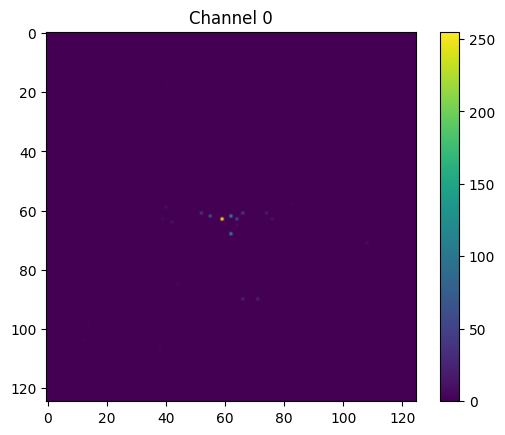

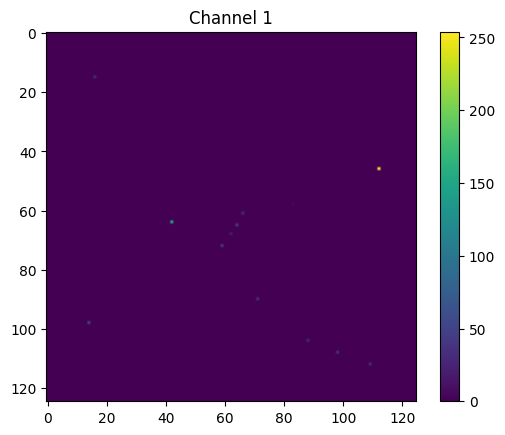

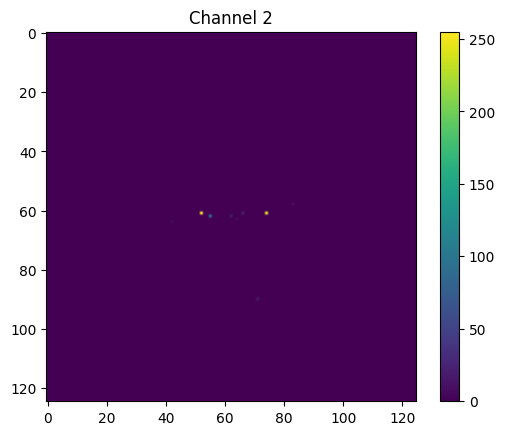

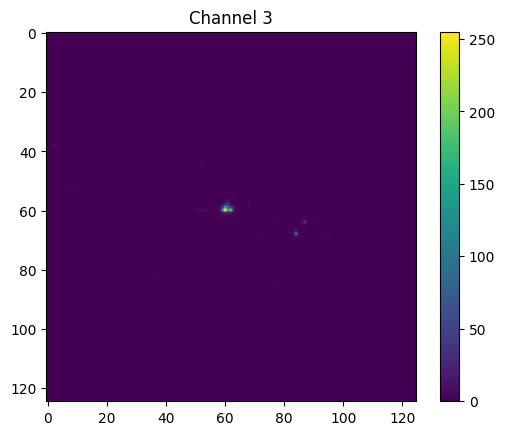

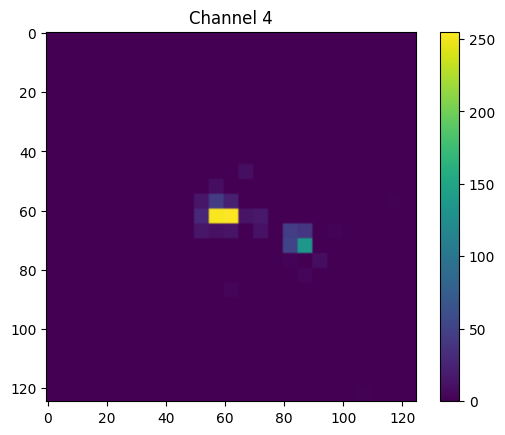

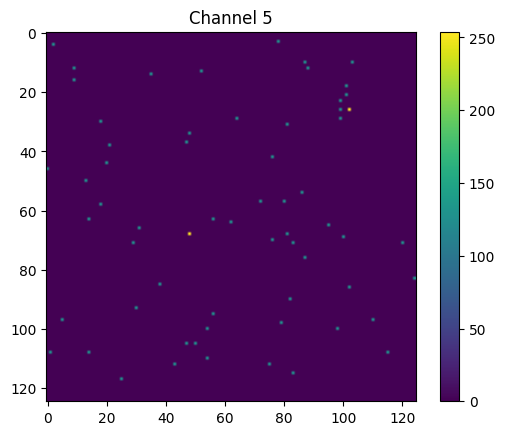

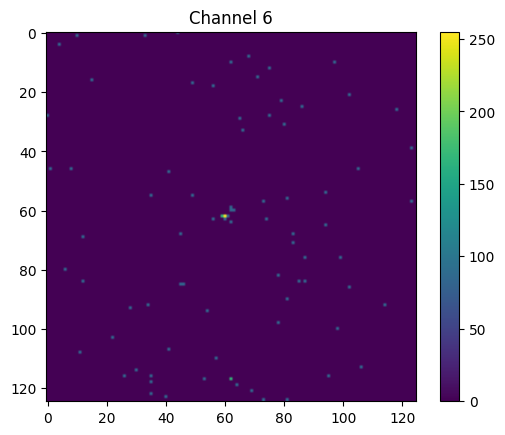

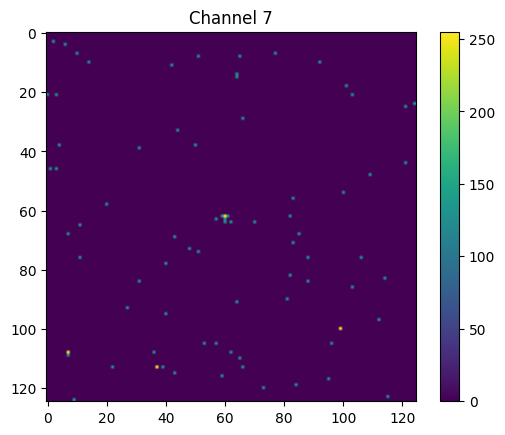

In [ ]:
for i in range(8):
    plt.figure()
    plt.imshow(img_sample[:, :, i], cmap="viridis")
    plt.title(f"Channel {i}")
    plt.colorbar()
    plt.show()

Visualize Pixel Distribution

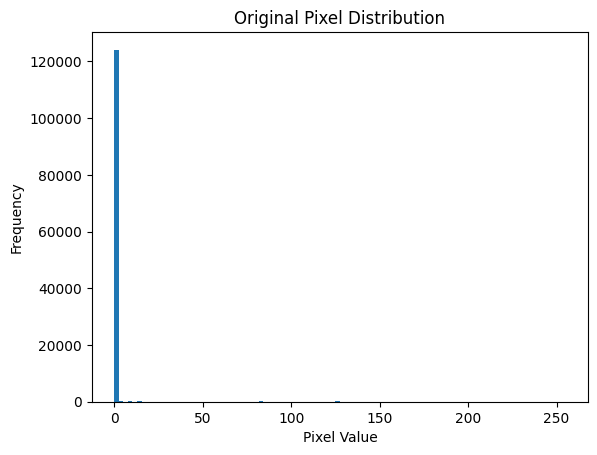

In [ ]:
plt.hist(img_sample.flatten(), bins=100)
plt.title("Original Pixel Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Compute Dataset-Wide Mean and Std

In [ ]:
def compute_mean_std(dataset, batch_size=100):
    n_samples = dataset.shape[0]

    mean = 0.0
    sq_mean = 0.0
    count = 0

    for i in range(0, n_samples, batch_size):
        batch = dataset[i:i+batch_size]

        batch = np.log1p(batch)  # apply log transform

        mean += np.sum(batch)
        sq_mean += np.sum(batch ** 2)
        count += np.prod(batch.shape)

    mean /= count
    std = np.sqrt((sq_mean / count) - (mean ** 2))

    return mean, std

mean, std = compute_mean_std(X_label)

print("Dataset Mean (log space):", mean)
print("Dataset Std (log space):", std)

Dataset Mean (log space): 0.0376301088
Dataset Std (log space): 0.37764450652922277


Final Preprocessing Function

In [ ]:
def preprocess_image(img, mean, std):
    img = np.log1p(img)              # log transform
    img = (img - mean) / (std + 1e-8)  # z-score normalize
    img = np.transpose(img, (2, 0, 1))  # convert to (C,H,W) for PyTorch
    return img.astype(np.float32)

Test Preprocessing

In [ ]:
processed_sample = preprocess_image(X_label[0], mean, std)

print("Processed Shape:", processed_sample.shape)
print("Processed Mean:", np.mean(processed_sample))
print("Processed Std:", np.std(processed_sample))

Processed Shape: (8, 125, 125)
Processed Mean: -0.03293465
Processed Std: 0.8173207


Label Distribution

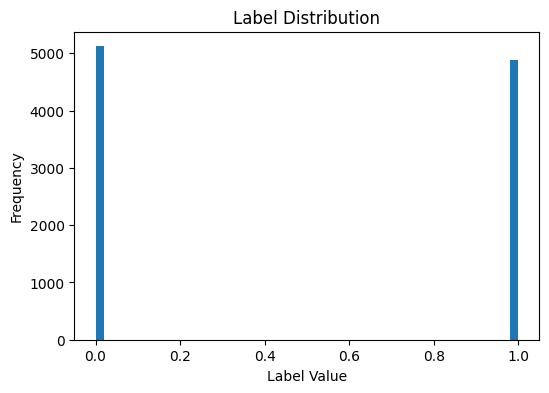

Min Label: 0.0
Max Label: 1.0
Mean Label: 0.4878


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

labels = f_label["Y"][:]

plt.figure(figsize=(6,4))
plt.hist(labels.flatten(), bins=50)
plt.title("Label Distribution")
plt.xlabel("Label Value")
plt.ylabel("Frequency")
plt.show()

print("Min Label:", np.min(labels))
print("Max Label:", np.max(labels))
print("Mean Label:", np.mean(labels))

Global Pixel Distribution

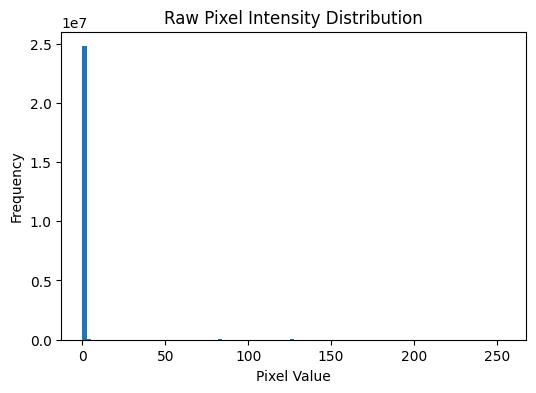

In [ ]:
sample_pixels = f_label["jet"][0:200].reshape(-1)  # 200 samples only

plt.figure(figsize=(6,4))
plt.hist(sample_pixels, bins=100)
plt.title("Raw Pixel Intensity Distribution")
plt.xlabel("Pixel Value")
plt.ylabel("Frequency")
plt.show()

Log-Transformed Distribution-generally applied for sparse scientific data

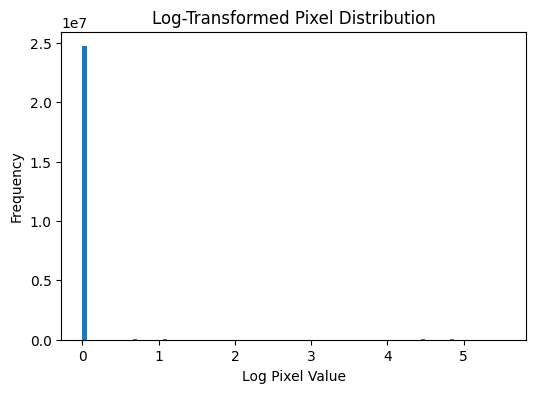

In [ ]:
log_pixels = np.log1p(sample_pixels)

plt.figure(figsize=(6,4))
plt.hist(log_pixels, bins=100)
plt.title("Log-Transformed Pixel Distribution")
plt.xlabel("Log Pixel Value")
plt.ylabel("Frequency")
plt.show()

Mean Intensity Per Channel

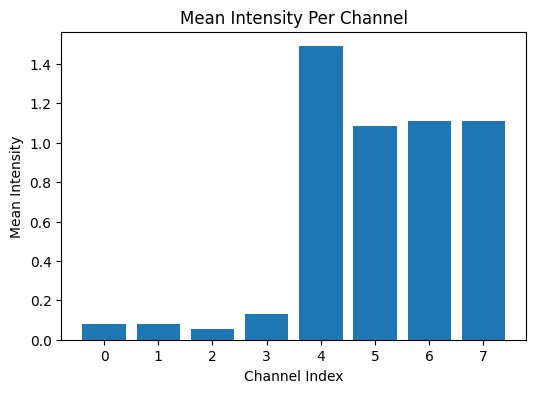

In [ ]:
channel_means = []

for c in range(8):
    channel_data = f_label["jet"][0:500, :, :, c]
    channel_means.append(np.mean(channel_data))

plt.figure(figsize=(6,4))
plt.bar(range(8), channel_means)
plt.title("Mean Intensity Per Channel")
plt.xlabel("Channel Index")
plt.ylabel("Mean Intensity")
plt.show()

Standard Deviation Per Channel

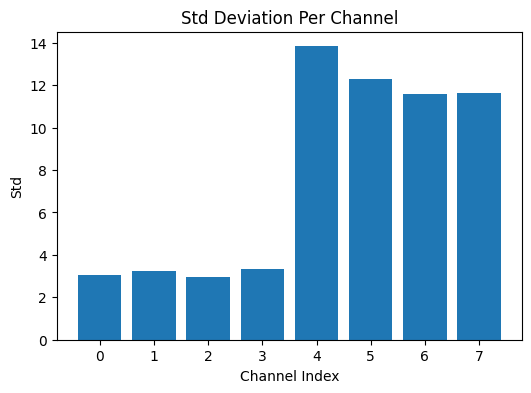

In [ ]:
channel_stds = []

for c in range(8):
    channel_data = f_label["jet"][0:500, :, :, c]
    channel_stds.append(np.std(channel_data))

plt.figure(figsize=(6,4))
plt.bar(range(8), channel_stds)
plt.title("Std Deviation Per Channel")
plt.xlabel("Channel Index")
plt.ylabel("Std")
plt.show()

Average Image Per Channel

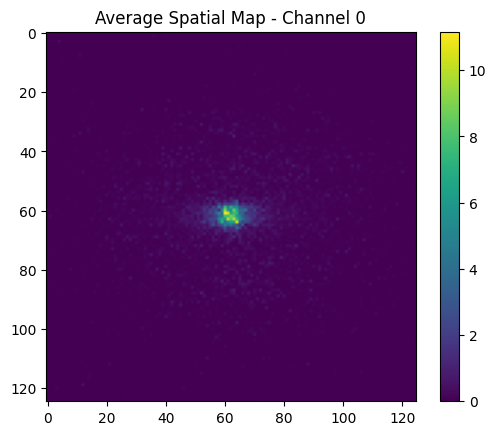

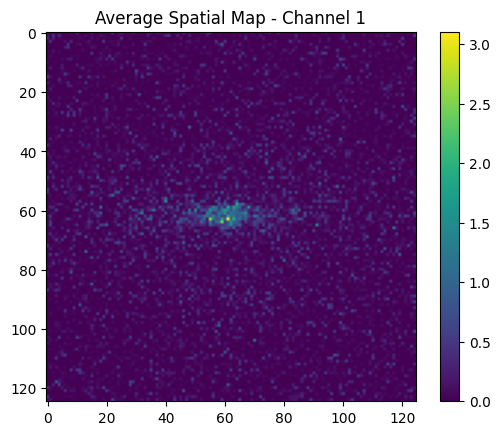

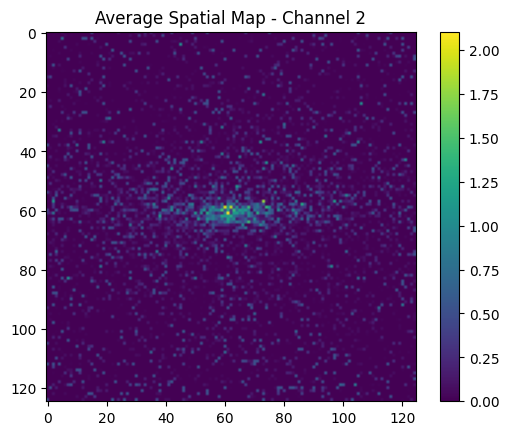

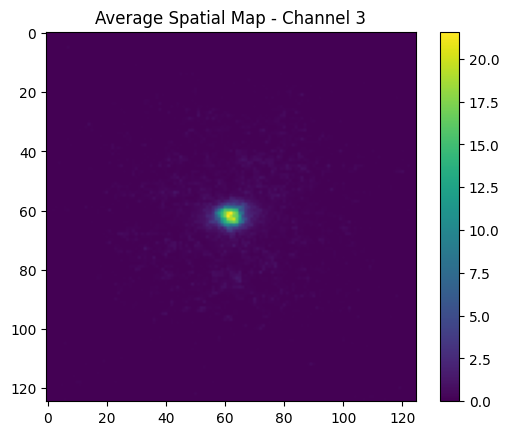

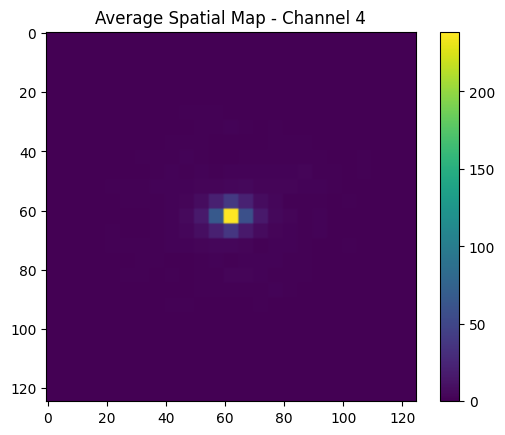

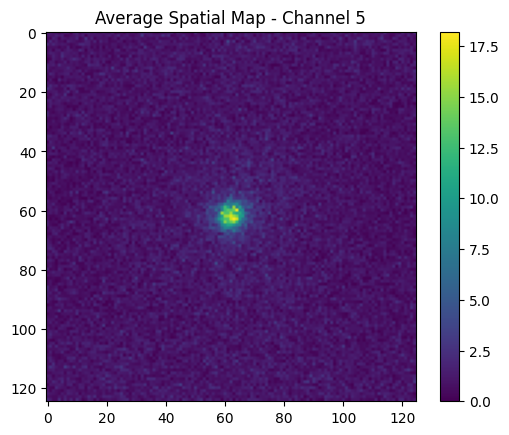

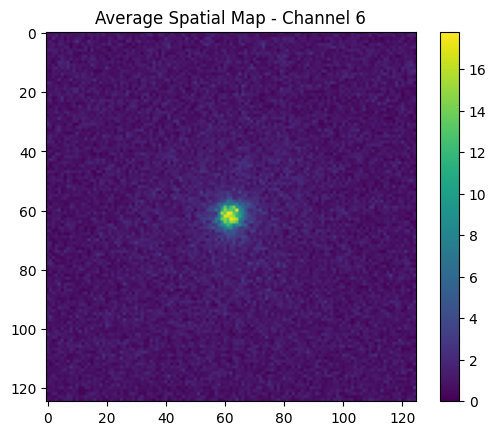

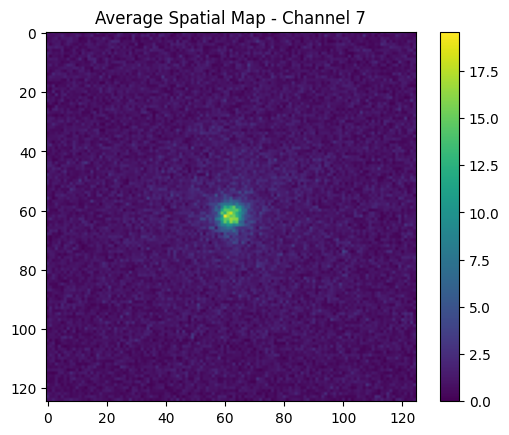

In [ ]:
avg_image = np.mean(f_label["jet"][0:500], axis=0)

for c in range(8):
    plt.figure()
    plt.imshow(avg_image[:, :, c], cmap="viridis")
    plt.title(f"Average Spatial Map - Channel {c}")
    plt.colorbar()
    plt.show()

Channel Correlation Matrix

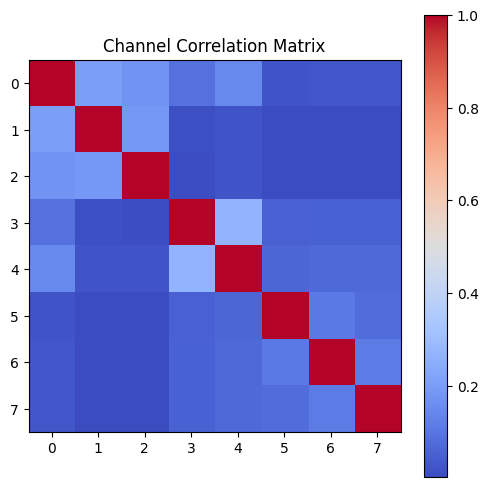

In [ ]:
subset = f_label["jet"][0:300]
subset = subset.reshape(-1, 8)

corr_matrix = np.corrcoef(subset.T)

plt.figure(figsize=(6,6))
plt.imshow(corr_matrix, cmap="coolwarm")
plt.colorbar()
plt.title("Channel Correlation Matrix")
plt.show()

Sparsity Analysis (Percentage of Zeros)

In [ ]:
subset = f_label["jet"][0:500]

zero_fraction = np.mean(subset == 0)

print("Fraction of Zero Pixels:", zero_fraction)

Fraction of Zero Pixels: 0.9879732


Total Energy Per Sample Distribution


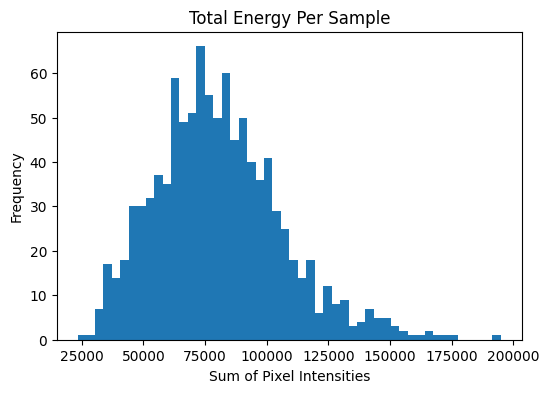

In [ ]:
subset = f_label["jet"][0:1000]

energy = np.sum(subset, axis=(1,2,3))

plt.figure(figsize=(6,4))
plt.hist(energy, bins=50)
plt.title("Total Energy Per Sample")
plt.xlabel("Sum of Pixel Intensities")
plt.ylabel("Frequency")
plt.show()

Energy vs Label Relationship

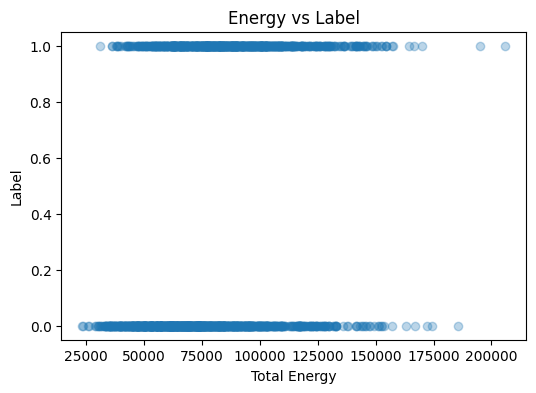

In [ ]:
energy = np.sum(f_label["jet"][0:2000], axis=(1,2,3))
labels_subset = labels[0:2000].flatten()

plt.figure(figsize=(6,4))
plt.scatter(energy, labels_subset, alpha=0.3)
plt.title("Energy vs Label")
plt.xlabel("Total Energy")
plt.ylabel("Label")
plt.show()

PCA Visualization

Feature shape: (5000, 8)
Explained Variance Ratio: [0.35200584 0.20995927]


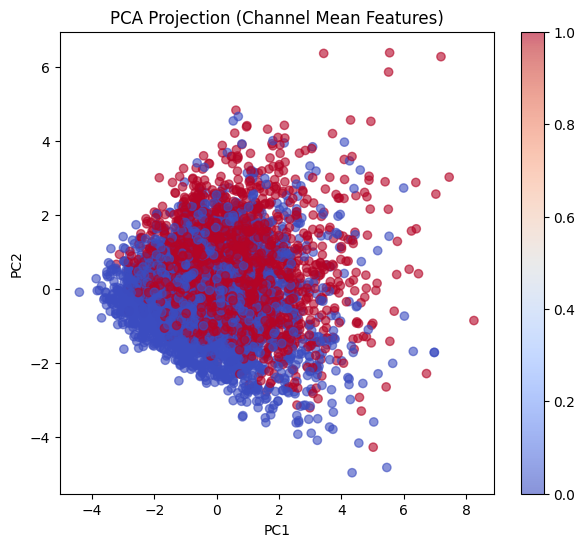

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
n_samples = 5000

subset = f_label["jet"][0:n_samples]
labels_subset = f_label["Y"][0:n_samples].flatten()
features = np.mean(subset, axis=(1,2))

print("Feature shape:", features.shape)

scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

pca = PCA(n_components=2)
pca_result = pca.fit_transform(features_scaled)

print("Explained Variance Ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(7,6))
scatter = plt.scatter(
    pca_result[:,0],
    pca_result[:,1],
    c=labels_subset,
    cmap="coolwarm",
    alpha=0.6
)

plt.colorbar(scatter)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA Projection (Channel Mean Features)")
plt.show()

Exploratory analysis shows that detector images contain sparse but structured energy deposits across channels. The pixel intensity distribution is highly skewed, requiring log normalization for stable learning. PCA visualization indicates partial class overlap, suggesting complex underlying patterns. These observations justify using deep learning models to capture spatial dependencies for classification and regression tasks.

Train / Validation Split

In [ ]:
path = "/content/Dataset_Specific_labelled.h5"

with h5py.File(path, "r") as f:

    print("Keys:", list(f.keys()))

    images_shape = f["jet"].shape
    labels_shape = f["Y"].shape

print("Images shape:", images_shape)
print("Labels shape:", labels_shape)

Keys: ['Y', 'jet']
Images shape: (10000, 125, 125, 8)
Labels shape: (10000, 1)


In [ ]:
with h5py.File(path,"r") as f:
    labels = f["Y"][:]

indices = np.arange(len(labels))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [ ]:
def compute_log_stats(h5_path, batch_size=100):

    with h5py.File(h5_path, "r") as f:

        data = f["jet"]
        n_samples = data.shape[0]

        total_sum = 0.0
        total_sq_sum = 0.0
        total_pixels = 0

        for i in range(0, n_samples, batch_size):

            batch = data[i:i+batch_size]     # load small batch
            batch = np.log1p(batch)

            total_sum += batch.sum()
            total_sq_sum += (batch**2).sum()

            total_pixels += np.prod(batch.shape)

        mean = total_sum / total_pixels
        variance = (total_sq_sum / total_pixels) - (mean**2)
        std = np.sqrt(variance)

    return mean, std

In [ ]:
from sklearn.metrics import roc_curve, auc as sk_auc

def plot_roc(targets, preds):

    fpr, tpr, _ = roc_curve(targets, preds)

    roc_auc = sk_auc(fpr, tpr)

    plt.figure()

    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
    plt.plot([0,1],[0,1],'--')

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")

    plt.title("ROC Curve")

    plt.legend()
    plt.show()

In [ ]:
path = "/content/Dataset_Specific_labelled.h5"

mean_log, std_log = compute_log_stats(path)

print("Mean:", mean_log)
print("Std:", std_log)

Mean: 0.0376301088
Std: 0.37764450652922277


In [ ]:
class JetDataset(Dataset):

    def __init__(self, path, indices, mean_log, std_log, mode="vit"):

        self.file = h5py.File(path, "r")
        self.jets = self.file["jet"]
        self.labels = self.file["Y"]

        self.indices = indices
        self.mean_log = mean_log
        self.std_log = std_log
        self.mode = mode


    def __len__(self):
        return len(self.indices)


    def __getitem__(self, idx):

        real_idx = self.indices[idx]

        img = torch.tensor(self.jets[real_idx], dtype=torch.float32)

        # regression target from RAW energy
        energy = torch.log1p(img.sum())

        # log normalization
        img = torch.log1p(img)
        img = (img - self.mean_log) / self.std_log

        img = img.permute(2,0,1)

        cls = torch.tensor(self.labels[real_idx][0], dtype=torch.float32)

        # CNN expects labels together
        if self.mode == "cnn":

            label = torch.stack([cls, energy])

            return img, label

        # ViT expects separate targets
        return img, cls, energy

We first establish a baseline using a Convolutional Neural Network (CNN). The CNN processes the 8-channel detector images and learns hierarchical spatial features useful for particle classification. Although CNNs are powerful for image analysis, they are limited in capturing long-range dependencies across the detector layers. This baseline serves as a reference to compare the performance of transformer-based models introduced later in the notebook

Baseline CNN model

In [ ]:
train_dataset = JetDataset(path, train_idx, mean_log, std_log, mode="cnn")
val_dataset = JetDataset(path, val_idx, mean_log, std_log, mode="cnn")
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
class MultiTaskCNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(8,32,3,padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(32,64,3,padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(64,128,3,padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.conv4 = nn.Conv2d(128,256,3,padding=1)
        self.bn4 = nn.BatchNorm2d(256)

        self.pool = nn.MaxPool2d(2)

        self.global_pool = nn.AdaptiveAvgPool2d((1,1))

        self.fc = nn.Linear(256,128)

        self.dropout = nn.Dropout(0.3)

        # Two heads
        self.cls_head = nn.Linear(128,1)
        self.reg_head = nn.Linear(128,1)

    def forward(self,x):

        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = self.pool(F.relu(self.bn4(self.conv4(x))))

        x = self.global_pool(x)

        x = torch.flatten(x,1)

        x = F.relu(self.fc(x))
        x = self.dropout(x)

        cls_out = self.cls_head(x)
        reg_out = self.reg_head(x)

        return cls_out, reg_out


model = MultiTaskCNN().to(device)


In [ ]:
cls_loss_fn = nn.BCEWithLogitsLoss()
reg_loss_fn = nn.MSELoss()
lambda_reg = 1e-5


optimizer = torch.optim.Adam(
    model.parameters(),
    lr=2e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2,
)


In [ ]:
energy_values = []

with h5py.File(path, "r") as f:

    jets = f["jet"]

    for i in range(len(jets)):
        energy = np.log1p(jets[i].sum())
        energy_values.append(energy)

energy_values = np.array(energy_values)

energy_mean = energy_values.mean()
energy_std = energy_values.std()

print("Energy mean:", energy_mean)
print("Energy std:", energy_std)

Energy mean: 11.262578
Energy std: 0.3249885


In [ ]:
def train_epoch(model, loader):

    model.train()

    total_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        cls_target = labels[:,0].unsqueeze(1)
        reg_target = labels[:,1].unsqueeze(1)

        optimizer.zero_grad()

        cls_pred, reg_pred = model(images)

        cls_loss = cls_loss_fn(cls_pred, cls_target)
        reg_loss = reg_loss_fn(reg_pred, reg_target)

        loss = cls_loss + lambda_reg * reg_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)



In [ ]:
def validate_epoch(model, loader):

    model.eval()

    total_loss = 0

    cls_preds = []
    cls_targets = []

    reg_preds = []
    reg_targets = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            cls_target = labels[:,0].unsqueeze(1)
            reg_target = labels[:,1].unsqueeze(1)

            cls_pred, reg_pred = model(images)

            cls_loss = cls_loss_fn(cls_pred, cls_target)
            reg_loss = reg_loss_fn(reg_pred, reg_target)

            loss = cls_loss + lambda_reg * reg_loss

            total_loss += loss.item()

            cls_preds.extend(torch.sigmoid(cls_pred).cpu().numpy())
            cls_targets.extend(cls_target.cpu().numpy())

            reg_preds.extend(reg_pred.cpu().numpy())
            reg_targets.extend(reg_target.cpu().numpy())

    auc_score = roc_auc_score(
        np.array(cls_targets).flatten(),
        np.array(cls_preds).flatten()
    )

    rmse = np.sqrt(mean_squared_error(reg_targets, reg_preds))

    return total_loss/len(loader), auc_score, rmse, cls_preds, cls_targets

In [ ]:
epochs = 10
best_auc = 0

for epoch in range(epochs):

    train_loss = train_epoch(model, train_loader)

    val_loss, val_auc, val_rmse, preds, targets = validate_epoch(model, val_loader)


    if val_auc > best_auc:

        best_auc = val_auc
        torch.save(model.state_dict(),"cnn_best.pth")

        print("New Best Model Saved")
    scheduler.step(val_auc)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}")
    print(f"Val AUC: {val_auc:.4f}")
    print(f"Val RMSE: {val_rmse:.4f}")
preds_cnn = preds
targets_cnn = targets


New Best Model Saved
Epoch 1
Train Loss: 0.4748
Val Loss: 0.9103
Val AUC: 0.9324
Val RMSE: 6.9556
New Best Model Saved
Epoch 2
Train Loss: 0.3413
Val Loss: 0.3661
Val AUC: 0.9385
Val RMSE: 4.8032
New Best Model Saved
Epoch 3
Train Loss: 0.2922
Val Loss: 0.3064
Val AUC: 0.9445
Val RMSE: 4.2832
New Best Model Saved
Epoch 4
Train Loss: 0.2678
Val Loss: 0.3631
Val AUC: 0.9468
Val RMSE: 2.7679
New Best Model Saved
Epoch 5
Train Loss: 0.2516
Val Loss: 0.3087
Val AUC: 0.9501
Val RMSE: 2.6199
Epoch 6
Train Loss: 0.2309
Val Loss: 1.7074
Val AUC: 0.9402
Val RMSE: 3.3839
Epoch 7
Train Loss: 0.2033
Val Loss: 1.1802
Val AUC: 0.9471
Val RMSE: 3.0484
Epoch 8
Train Loss: 0.1818
Val Loss: 0.7836
Val AUC: 0.9454
Val RMSE: 2.8028
Epoch 9
Train Loss: 0.1100
Val Loss: 0.4479
Val AUC: 0.9416
Val RMSE: 2.4867
Epoch 10
Train Loss: 0.0910
Val Loss: 2.4276
Val AUC: 0.9280
Val RMSE: 3.8321


## APPROACH 1- Linear vision transformer (scratch + finetuning) + TTA + Early stopping

Next, we train a Vision Transformer with linear attention directly on the labeled dataset. The input detector images are first divided into fixed-size patches, which are embedded into tokens and processed by transformer blocks.

To handle the high-resolution detector images efficiently, we use linear attention, which reduces the computational complexity from O(N2) to O(N) with respect to the number of patches.

In [ ]:
def tta_predict(model, images):

    model.eval()

    with torch.no_grad():

        images = images.to(device)

        # original
        p1 = torch.sigmoid(model(images)[0])

        # horizontal flip
        p2 = torch.sigmoid(model(torch.flip(images, [3]))[0])

        # vertical flip
        p3 = torch.sigmoid(model(torch.flip(images, [2]))[0])

        #diagonal flip
        p4 = torch.sigmoid(model(torch.flip(images,[2,3]))[0])

    return (p1+p2+p3+p4)/4

In [ ]:
class EarlyStopping:

    def __init__(self, patience=5, min_delta=0):

        self.patience = patience
        self.min_delta = min_delta

        self.best_score = None
        self.counter = 0
        self.early_stop = False

    def step(self, metric):

        if self.best_score is None:
            self.best_score = metric
            return False

        if metric < self.best_score + self.min_delta:

            self.counter += 1

            if self.counter >= self.patience:
                self.early_stop = True

        else:
            self.best_score = metric
            self.counter = 0

        return self.early_stop

Linear Vision Transformer (Scratch)

In [ ]:
train_dataset = JetDataset(
    path,
    train_idx,
    mean_log,
    std_log,
    mode="vit"
)

val_dataset = JetDataset(
    path,
    val_idx,
    mean_log,
    std_log,
    mode="vit"
)

In [ ]:
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [ ]:
class PatchEmbedding(nn.Module):

    def __init__(self, patch=5, dim=128):

        super().__init__()

        self.patch = patch
        self.proj = nn.Linear(8*patch*patch, dim)

    def forward(self,x):

        B,C,H,W = x.shape
        p = self.patch

        x = x.unfold(2,p,p).unfold(3,p,p)
        x = x.contiguous().view(B,C,-1,p,p)

        x = x.permute(0,2,1,3,4)
        x = x.reshape(B,-1,C*p*p)

        return self.proj(x)

In [ ]:
class LinearAttention(nn.Module):

    def __init__(self,dim):

        super().__init__()

        self.q = nn.Linear(dim,dim)
        self.k = nn.Linear(dim,dim)
        self.v = nn.Linear(dim,dim)

        self.proj = nn.Linear(dim,dim)

    def forward(self,x):

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        Q = torch.softmax(Q,dim=-1)
        K = torch.softmax(K,dim=-2)

        context = torch.einsum("bnd,bne->bde",K,V)

        out = torch.einsum("bnd,bde->bne",Q,context)

        return self.proj(out)

In [ ]:
class TransformerBlock(nn.Module):

    def __init__(self,dim):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = LinearAttention(dim)

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim,dim*4),
            nn.GELU(),
            nn.Linear(dim*4,dim)
        )

    def forward(self,x):

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

In [ ]:
class LinearViT(nn.Module):

    def __init__(self,dim=128,depth=6):

        super().__init__()

        self.patch_embed = PatchEmbedding()

        self.cls_token = nn.Parameter(torch.randn(1,1,dim))
        self.pos_embed = nn.Parameter(torch.randn(1,626,dim))

        self.blocks = nn.ModuleList(
            [TransformerBlock(dim) for _ in range(depth)]
        )

        self.norm = nn.LayerNorm(dim)

        self.cls_head = nn.Linear(dim,1)
        self.reg_head = nn.Linear(dim,1)

    def forward(self,x):

        x = self.patch_embed(x)

        B,N,D = x.shape

        cls = self.cls_token.expand(B,-1,-1)

        x = torch.cat([cls,x],1)

        x = x + self.pos_embed[:,:N+1]

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        cls_token = x[:,0]

        cls_out = self.cls_head(cls_token)
        reg_out = self.reg_head(cls_token)

        return cls_out.view(-1), reg_out.view(-1)

In [ ]:
bce = nn.BCEWithLogitsLoss()
mse = nn.MSELoss()

LAMBDA = 1e-5


def compute_loss(pred_cls, pred_reg, cls, reg):

    loss_cls = bce(pred_cls, cls)
    loss_reg = mse(pred_reg, reg)

    loss = loss_cls + LAMBDA * loss_reg

    return loss

In [ ]:
def train_epoch(model, loader, optimizer):

    model.train()

    total_loss = 0

    for img, cls, reg in loader:

        img = img.to(device)
        cls = cls.to(device)
        reg = reg.to(device)

        pred_cls, pred_reg = model(img)

        loss = compute_loss(pred_cls, pred_reg, cls, reg)

        optimizer.zero_grad()

        loss.backward()

        # prevents exploding gradients
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)

In [ ]:
def evaluate(model, loader):

    model.eval()

    preds = []
    targets = []

    reg_preds = []
    reg_targets = []

    with torch.no_grad():

        for img, cls, reg in loader:

            img = img.to(device)

            prob = tta_predict(model, img)

            _, pred_reg = model(img)

            preds.extend(prob.cpu().numpy())
            targets.extend(cls.numpy())

            reg_preds.extend(pred_reg.cpu().numpy())
            reg_targets.extend(reg.numpy())

    preds = np.array(preds)
    targets = np.array(targets)

    reg_preds = np.array(reg_preds)
    reg_targets = np.array(reg_targets)

    mask = ~np.isnan(preds)

    preds = preds[mask]
    targets = targets[mask]

    reg_preds = np.nan_to_num(reg_preds)
    reg_targets = np.nan_to_num(reg_targets)

    auc_score = roc_auc_score(targets, preds)

    rmse = np.sqrt(mean_squared_error(reg_targets, reg_preds))

    return auc_score, rmse, preds, targets

In [ ]:
model1 = LinearViT().to(device)

optimizer = torch.optim.AdamW(
    model1.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

early_stopping = EarlyStopping(patience=5)

losses = []
vit_auc_scores = []
vit_rmse_scores = []

epochs = 10

for epoch in range(epochs):

    loss = train_epoch(model1, train_loader, optimizer)


    auc, rmse, preds, targets = evaluate(model1, val_loader)

    losses.append(loss)
    vit_auc_scores.append(auc)
    vit_rmse_scores.append(rmse)

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {loss:.4f}")
    print(f"Val AUC: {auc:.4f}")
    print(f"Val RMSE: {rmse:.4f}")

    if early_stopping.step(auc):
        print("Early stopping triggered")
        break

preds_vit = preds
targets_vit = targets

Epoch 1
Train Loss: 0.5445
Val AUC: 0.8426
Val RMSE: 7.4124
Epoch 2
Train Loss: 0.5030
Val AUC: 0.8492
Val RMSE: 4.4149
Epoch 3
Train Loss: 0.4894
Val AUC: 0.8530
Val RMSE: 3.0268
Epoch 4
Train Loss: 0.4865
Val AUC: 0.8584
Val RMSE: 1.7005
Epoch 5
Train Loss: 0.4640
Val AUC: 0.8811
Val RMSE: 1.8479
Epoch 6
Train Loss: 0.4377
Val AUC: 0.8983
Val RMSE: 1.5759
Epoch 7
Train Loss: 0.4059
Val AUC: 0.9104
Val RMSE: 2.0171
Epoch 8
Train Loss: 0.3842
Val AUC: 0.9202
Val RMSE: 2.5741
Epoch 9
Train Loss: 0.3842
Val AUC: 0.9201
Val RMSE: 1.6304
Epoch 10
Train Loss: 0.3650
Val AUC: 0.9256
Val RMSE: 1.9344


Linear Vision Transformer — Fine-Tuning

To improve performance, we fine-tune the previously trained Linear Vision Transformer using a lower learning rate. During fine-tuning, early layers of the transformer backbone are partially frozen to preserve previously learned representations while allowing the prediction heads to adapt to the labeled dataset.

In [ ]:
torch.save(model1.state_dict(),"linearvit_scratch.pth")

In [ ]:
finetune_model = LinearViT().to(device)

finetune_model.load_state_dict(
    torch.load("linearvit_scratch.pth", map_location=device)
)

In [ ]:
for param in finetune_model.patch_embed.parameters():
    param.requires_grad = False

finetune_model.cls_token.requires_grad = False
finetune_model.pos_embed.requires_grad = False

In [ ]:
optimizer = torch.optim.AdamW(

[
    {"params": finetune_model.blocks.parameters(), "lr": 1e-5},
    {"params": finetune_model.cls_head.parameters(), "lr": 1e-4},
    {"params": finetune_model.reg_head.parameters(), "lr": 1e-4},
],

weight_decay=1e-4
)

In [ ]:
early_stopping_ft = EarlyStopping(patience=5)

finetune_losses = []
finetune_auc_scores = []
finetune_rmse_scores = []

epochs = 10

for epoch in range(epochs):

    loss = train_epoch(finetune_model, train_loader, optimizer)

    auc, rmse, preds, targets = evaluate(finetune_model, val_loader)

    finetune_losses.append(loss)
    finetune_auc_scores.append(auc)
    finetune_rmse_scores.append(rmse)

    print(f"Finetune Epoch {epoch+1}")
    print(f"Loss: {loss:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"RMSE: {rmse:.4f}")

    if early_stopping_ft.step(auc):

        print("Early stopping triggered (finetune)")
        break

preds_vit_ft = preds
targets_vit_ft = targets

Finetune Epoch 1
Loss: 0.3066
AUC: 0.9262
RMSE: 1.7095
Finetune Epoch 2
Loss: 0.3063
AUC: 0.9269
RMSE: 1.6064
Finetune Epoch 3
Loss: 0.3014
AUC: 0.9269
RMSE: 1.6420
Finetune Epoch 4
Loss: 0.2997
AUC: 0.9273
RMSE: 1.5238
Finetune Epoch 5
Loss: 0.2964
AUC: 0.9272
RMSE: 1.5641
Finetune Epoch 6
Loss: 0.2942
AUC: 0.9278
RMSE: 1.7098
Finetune Epoch 7
Loss: 0.2937
AUC: 0.9281
RMSE: 1.7705
Finetune Epoch 8
Loss: 0.2934
AUC: 0.9278
RMSE: 1.6974
Finetune Epoch 9
Loss: 0.2913
AUC: 0.9278
RMSE: 1.6449
Finetune Epoch 10
Loss: 0.2900
AUC: 0.9283
RMSE: 1.5614


In [ ]:
torch.save(
    finetune_model.state_dict(),
    "linearvit_finetuned.pth"
)

## APPROACH-2 Performer Vision Transformer(scratch + finetuning) + TTA + Early stopping

We further explore a Performer-based Vision Transformer, which implements an efficient linear attention mechanism using kernel feature maps. This architecture approximates standard self-attention while maintaining linear computational complexity, making it suitable for large detector images.

As before, the detector images are converted into patch embeddings and processed through transformer blocks.

In [ ]:
class PerformerAttention(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.q = nn.Linear(dim, dim)
        self.k = nn.Linear(dim, dim)
        self.v = nn.Linear(dim, dim)

    def forward(self, x):

        Q = self.q(x)
        K = self.k(x)
        V = self.v(x)

        # Performer kernel feature map
        Q = F.elu(Q) + 1
        K = F.elu(K) + 1

        KV = torch.einsum("bnd,bne->bde", K, V)

        Z = 1 / (torch.einsum("bnd,bd->bn", Q, K.sum(dim=1)) + 1e-6)

        out = torch.einsum("bnd,bde,bn->bne", Q, KV, Z)

        return out

In [ ]:
class PerformerBlock(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.norm1 = nn.LayerNorm(dim)
        self.attn = PerformerAttention(dim)

        self.norm2 = nn.LayerNorm(dim)

        self.mlp = nn.Sequential(
            nn.Linear(dim, dim*4),
            nn.GELU(),
            nn.Linear(dim*4, dim)
        )

    def forward(self, x):

        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))

        return x

In [ ]:
class PerformerViT(nn.Module):

    def __init__(self, image_size=125, patch=5, dim=128, depth=6):

        super().__init__()

        num_patches = (image_size // patch) ** 2
        patch_dim = 8 * patch * patch

        self.patch = patch

        self.patch_embed = nn.Linear(patch_dim, dim)

        self.cls_token = nn.Parameter(torch.randn(1,1,dim))
        self.pos_embed = nn.Parameter(torch.randn(1,num_patches+1,dim))

        self.blocks = nn.ModuleList([
            PerformerBlock(dim) for _ in range(depth)
        ])

        self.norm = nn.LayerNorm(dim)

        self.cls_head = nn.Linear(dim,1)
        self.reg_head = nn.Linear(dim,1)

    def patchify(self,x):

        B,C,H,W = x.shape
        p = self.patch

        x = x.unfold(2,p,p).unfold(3,p,p)
        x = x.contiguous().view(B,C,-1,p,p)

        x = x.permute(0,2,1,3,4)
        x = x.reshape(B,-1,C*p*p)

        return x

    def forward(self,x):

        x = self.patchify(x)

        x = self.patch_embed(x)

        B,N,D = x.shape

        cls = self.cls_token.expand(B,-1,-1)

        x = torch.cat([cls,x],1)

        x = x + self.pos_embed[:,:N+1]

        for blk in self.blocks:
            x = blk(x)

        x = self.norm(x)

        cls_token = x[:,0]

        cls_out = self.cls_head(cls_token)
        reg_out = self.reg_head(cls_token)

        return cls_out.view(-1), reg_out.view(-1)

In [ ]:
model2 = PerformerViT().to(device)

optimizer = torch.optim.AdamW(model2.parameters(), lr=3e-4)

early_stopping = EarlyStopping(patience=3)

perf_losses=[]
perf_auc=[]
perf_rmse=[]

epochs = 10

for epoch in range(epochs):

    loss = train_epoch(model2, train_loader, optimizer)

    auc, rmse, preds, targets = evaluate(model2, val_loader)

    perf_losses.append(loss)
    perf_auc.append(auc)
    perf_rmse.append(rmse)

    print(f"Epoch {epoch+1}")
    print(f"Loss {loss:.4f}")
    print(f"AUC {auc:.4f}")
    print(f"RMSE {rmse:.4f}")

    # Early stopping check
    early_stopping.step(auc)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break
preds_perf = preds
targets_perf = targets

Epoch 1
Loss 0.5330
AUC 0.8469
RMSE 3.0851
Epoch 2
Loss 0.5002
AUC 0.8505
RMSE 1.8279
Epoch 3
Loss 0.4817
AUC 0.8670
RMSE 1.6386
Epoch 4
Loss 0.4379
AUC 0.9013
RMSE 1.6211
Epoch 5
Loss 0.4040
AUC 0.9182
RMSE 1.8594
Epoch 6
Loss 0.3742
AUC 0.9275
RMSE 2.1439
Epoch 7
Loss 0.3509
AUC 0.9239
RMSE 1.8291
Epoch 8
Loss 0.3460
AUC 0.9269
RMSE 3.3387
Epoch 9
Loss 0.3158
AUC 0.9262
RMSE 1.9015
Early stopping triggered


Performer Vision Transformer — Fine-Tuning

Finally, the Performer model is fine-tuned using a smaller learning rate. During this stage, the early embedding layers are frozen to preserve the learned feature representations, while the later transformer blocks and prediction heads are allowed to adapt to the labeled data.

In [208]:
torch.save(model2.state_dict(),"performer_scratch.pth")

In [209]:
performer_finetune = PerformerViT().to(device)

performer_finetune.load_state_dict(torch.load("performer_scratch.pth"))

<All keys matched successfully>

In [210]:
for param in performer_finetune.patch_embed.parameters():
    param.requires_grad = False

for param in performer_finetune.blocks[:3].parameters():
    param.requires_grad = False

In [211]:
optimizer = torch.optim.AdamW([

    {"params": performer_finetune.blocks.parameters(), "lr":1e-5},

    {"params": performer_finetune.cls_head.parameters(), "lr":1e-4},

    {"params": performer_finetune.reg_head.parameters(), "lr":1e-4}

], weight_decay=1e-4)

In [212]:
criterion_cls = torch.nn.BCEWithLogitsLoss()
criterion_reg = torch.nn.MSELoss()

LAMBDA = 1e-5

In [213]:
early_stopping = EarlyStopping(patience=3)

performer_finetune_losses=[]
performer_finetune_auc=[]
performer_finetune_rmse=[]

epochs = 10

for epoch in range(epochs):

    loss = train_epoch(performer_finetune, train_loader, optimizer)

    auc, rmse, preds, targets = evaluate(performer_finetune, val_loader)

    performer_finetune_losses.append(loss)
    performer_finetune_auc.append(auc)
    performer_finetune_rmse.append(rmse)

    print(f"Epoch {epoch+1}")
    print(f"Finetune Loss: {loss:.4f}")
    print(f"Val AUC: {auc:.4f}")
    print(f"Val RMSE: {rmse:.4f}")
    early_stopping.step(auc)

    if early_stopping.early_stop:
        print("Early stopping triggered")
        break
preds_perf_ft = preds
targets_perf_ft = targets

Epoch 1
Finetune Loss: 0.2596
Val AUC: 0.9287
Val RMSE: 1.6981
Epoch 2
Finetune Loss: 0.2568
Val AUC: 0.9292
Val RMSE: 1.7147
Epoch 3
Finetune Loss: 0.2558
Val AUC: 0.9295
Val RMSE: 1.7201
Epoch 4
Finetune Loss: 0.2554
Val AUC: 0.9297
Val RMSE: 1.7106
Epoch 5
Finetune Loss: 0.2546
Val AUC: 0.9299
Val RMSE: 1.7201
Epoch 6
Finetune Loss: 0.2546
Val AUC: 0.9300
Val RMSE: 1.6962
Epoch 7
Finetune Loss: 0.2540
Val AUC: 0.9300
Val RMSE: 1.6703
Epoch 8
Finetune Loss: 0.2538
Val AUC: 0.9301
Val RMSE: 1.6491
Epoch 9
Finetune Loss: 0.2530
Val AUC: 0.9302
Val RMSE: 1.6255
Epoch 10
Finetune Loss: 0.2527
Val AUC: 0.9303
Val RMSE: 1.6205


In [ ]:
torch.save(
    performer_finetune.state_dict(),
    "performer_finetuned.pth"
)

BASELINE CNN


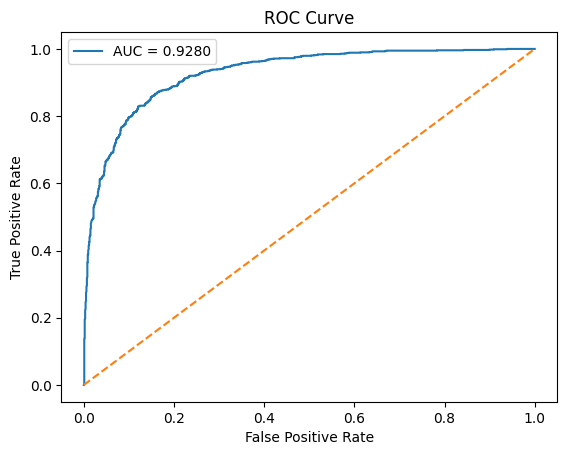

LINEAR VIT


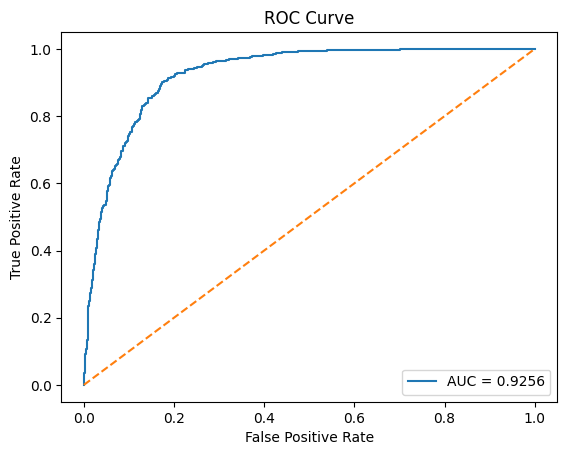

FINETUNED LINEAR VIT


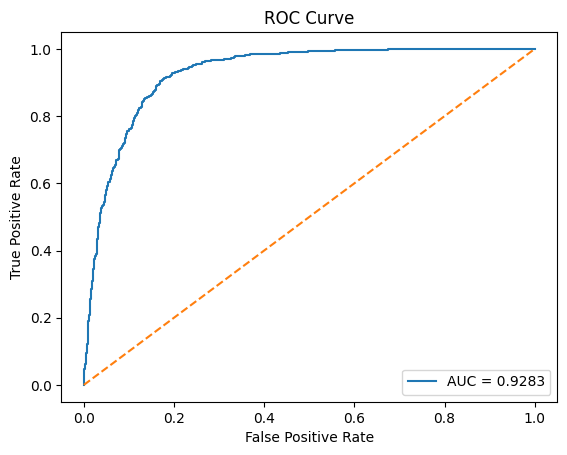

PERFORMER VIT


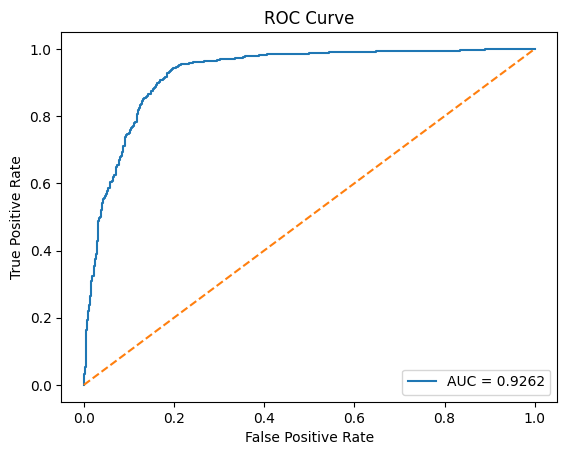

FINETUNED PERFORMER VIT


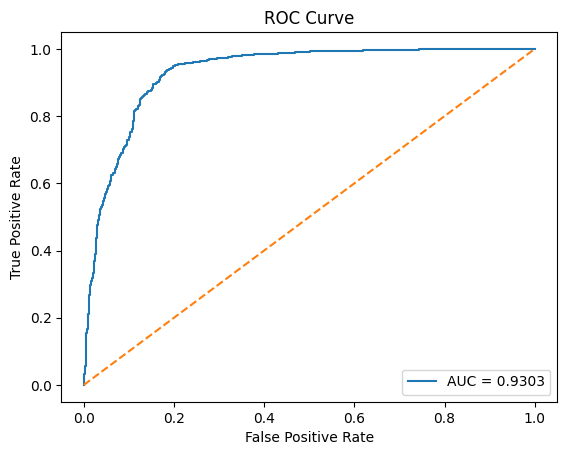

In [214]:
print("BASELINE CNN")
plot_roc(
    np.array(targets_cnn).flatten(),
    np.array(preds_cnn).flatten()
)

print("LINEAR VIT")
plot_roc(
    np.array(targets_vit).flatten(),
    np.array(preds_vit).flatten()
)

print("FINETUNED LINEAR VIT")
plot_roc(
    np.array(targets_vit_ft).flatten(),
    np.array(preds_vit_ft).flatten()
)

print("PERFORMER VIT")
plot_roc(
    np.array(targets_perf).flatten(),
    np.array(preds_perf).flatten()
)

print("FINETUNED PERFORMER VIT")
plot_roc(
    np.array(targets_perf_ft).flatten(),
    np.array(preds_perf_ft).flatten()
)

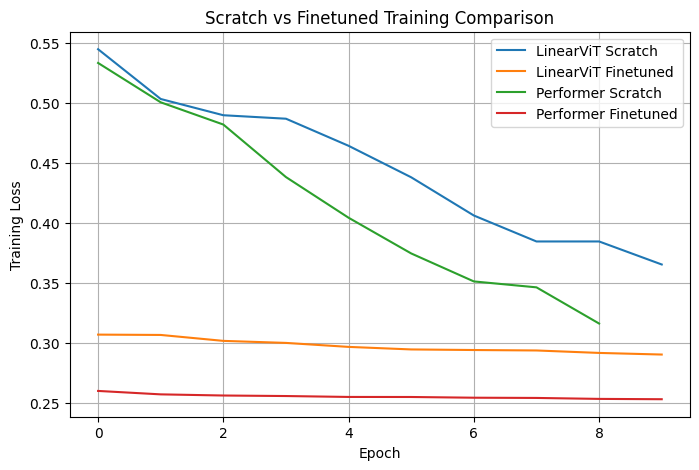

In [215]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

if len(losses) > 0:
    plt.plot(range(len(losses)), losses, label="LinearViT Scratch")

if len(finetune_losses) > 0:
    plt.plot(range(len(finetune_losses)), finetune_losses, label="LinearViT Finetuned")

if len(perf_losses) > 0:
    plt.plot(range(len(perf_losses)), perf_losses, label="Performer Scratch")

if len(performer_finetune_losses) > 0:
    plt.plot(range(len(performer_finetune_losses)), performer_finetune_losses, label="Performer Finetuned")

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Scratch vs Finetuned Training Comparison")

plt.legend()
plt.grid(True)

plt.show()

In [216]:
import pandas as pd

auc1 = max(vit_auc_scores)
auc2 = max(finetune_auc_scores)
auc3 = max(perf_auc)
auc4 = max(performer_finetune_auc)

rmse1 = min(vit_rmse_scores)
rmse2 = min(finetune_rmse_scores)
rmse3 = min(perf_rmse)
rmse4 = min(performer_finetune_rmse)

results = {
    "Model":[
        "LinearViT Scratch",
        "LinearViT Finetuned",
        "PerformerViT Scratch",
        "PerformerViT Finetuned"
    ],

    "Best AUC":[
        round(auc1,4),
        round(auc2,4),
        round(auc3,4),
        round(auc4,4)
    ],

    "Best RMSE":[
        round(rmse1,4),
        round(rmse2,4),
        round(rmse3,4),
        round(rmse4,4)
    ]
}

df = pd.DataFrame(results)

# Sort by performance
df = df.sort_values(by="Best AUC", ascending=False)

print("\n===== FINAL MODEL COMPARISON =====")
print(df)


===== FINAL MODEL COMPARISON =====
                    Model  Best AUC  Best RMSE
3  PerformerViT Finetuned    0.9303     1.6205
1     LinearViT Finetuned    0.9283     1.5238
2    PerformerViT Scratch    0.9275     1.6211
0       LinearViT Scratch    0.9256     1.5759


CNN--> Linear in pixels O(HW)

LinearViT--> Linear O(N)

PerformerViT--> Linear O(N)





This study evaluated linear-attention transformer architectures for multi-task analysis of particle detector images, performing both particle classification and regression of a derived energy-related property. Among the tested models, the PerformerViT Finetuned achieved the highest classification performance with an AUC of 0.9303, while LinearVIT finetuned achieved the lowest RMSE of 1.5238, indicating strong regression capability. Overall, Performer-based models slightly outperformed LinearViT variants, demonstrating the effectiveness of kernel-based linear attention in capturing global detector patterns. These results show that efficient transformer architectures with linear complexity can successfully model high-resolution detector data while maintaining strong predictive performance for both classification and regression tasks.

# **MADE BY- KRRISH KUMAR**